# 单谱预处理对照（ramanv2）

下方单元直接使用 `ramanv2` 展示宇宙射线处理、基线估计和方法对比。


In [29]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import seaborn as sns


def find_project_root(start: Path | None = None) -> Path:
    """从当前目录向上查找 ramanv2 与 dataset 所在的项目根目录。"""
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "ramanv2").is_dir() and (candidate / "dataset").is_dir():
            return candidate
    raise FileNotFoundError("未找到同时包含 ramanv2 和 dataset 的项目根目录")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ramanv2.core.config import build_config
from ramanv2.data.config import resolve_build_config, resolve_cosmic_options
from ramanv2.data.io import read_arc_data
from ramanv2.data.profiles import get_dataset_dir, get_profile
from ramanv2.spectra.bands import build_valid_mask
from ramanv2.spectra.preprocess import estimate_baseline, remove_cosmic_rays


def resolve_sample_path(profile, sample_path, sample_folder, sample_seed):
    """解析指定样本或从指定文件夹稳定抽取一条谱。"""
    dataset_dir = get_dataset_dir(profile, PROJECT_ROOT)
    if sample_path is not None:
        path = Path(sample_path)
        return path if path.is_absolute() else PROJECT_ROOT / path

    root = Path(sample_folder) if sample_folder else dataset_dir / profile.root_init
    if not root.is_absolute():
        project_path = PROJECT_ROOT / root
        root = project_path if project_path.exists() else dataset_dir / root
    candidates = sorted(root.rglob("*.arc_data"))
    if not candidates:
        raise FileNotFoundError(f"未找到 .arc_data 文件：{root}")
    return random.Random(sample_seed).choice(candidates)


def plot_curve(ax, wavenumbers, intensity, mask, label, **kwargs):
    """绘制有效波段，坏波段以空隙保留。"""
    curve = np.asarray(intensity, dtype=np.float32).copy()
    curve[~mask] = np.nan
    ax.plot(wavenumbers, curve, label=label, **kwargs)


def add_bad_band_spans(ax, bad_bands):
    """在图中标记不参与模型输入的坏波段。"""
    for index, (lower, upper) in enumerate(bad_bands):
        ax.axvspan(lower, upper, color="gray", alpha=0.14, label="bad band" if index == 0 else None)


def style_axis(ax, title, bad_bands, display_min, display_max, ylabel="Intensity"):
    """统一预处理图的坐标轴和波段标记。"""
    add_bad_band_spans(ax, bad_bands)
    ax.set_title(title)
    ax.set_xlabel("Wavenumber (cm$^{-1}$)")
    ax.set_ylabel(ylabel)
    if display_min is not None and display_max is not None:
        ax.set_xlim(display_min, display_max)
    ax.legend(loc="best")


def show_preprocess(
    *,
    profile_id="GN",
    sample_path=None,
    sample_folder=None,
    sample_seed=None,
    display_min=None,
    display_max=None,
    compare_baselines=True,
):
    """展示 ramanv2 的宇宙射线清理、基线估计及方法对比。"""
    profile = get_profile(profile_id)
    path = resolve_sample_path(profile, sample_path, sample_folder, sample_seed)
    wavenumbers, raw_intensity = read_arc_data(path)
    if wavenumbers.size == 0 or raw_intensity.size == 0:
        raise ValueError(f"无法读取光谱：{path}")

    input_config = build_config({"profile_id": profile_id}).input
    build_config_value = resolve_build_config()
    try:
        label = path.relative_to(get_dataset_dir(profile, PROJECT_ROOT)).as_posix()
    except ValueError:
        label = path.name
    cosmic_options = resolve_cosmic_options(profile, build_config_value, label)
    if cosmic_options["cosmic_ray_enable"]:
        clean_intensity, cosmic_stats = remove_cosmic_rays(
            raw_intensity,
            window_points=cosmic_options["cosmic_ray_window_points"],
            threshold=cosmic_options["cosmic_ray_threshold"],
            max_iter=cosmic_options["cosmic_ray_max_iter"],
        )
    else:
        clean_intensity = np.asarray(raw_intensity, dtype=np.float32)
        cosmic_stats = 0

    fit_mask = (
        (wavenumbers >= build_config_value.baseline_fit_min)
        & (wavenumbers <= build_config_value.baseline_fit_max)
    )
    fit_wavenumbers = wavenumbers[fit_mask]
    fit_intensity = clean_intensity[fit_mask]
    valid_mask = build_valid_mask(fit_wavenumbers, input_config.bad_bands)
    method_names = [build_config_value.baseline_method]
    if compare_baselines:
        for candidate in ("airPLS", "asLS"):
            if candidate.lower() not in {name.lower() for name in method_names}:
                method_names.append(candidate)

    baselines = {}
    for method in method_names:
        baselines[method] = estimate_baseline(
            fit_intensity,
            method=method,
            lam=build_config_value.baseline_lam,
            p=build_config_value.baseline_asls_p,
            niter=build_config_value.baseline_max_iter,
            valid_mask=valid_mask,
        )
    full_mask = build_valid_mask(wavenumbers, input_config.bad_bands)

    print(f"sample_path = {path}")
    print(f"cosmic_ray_replaced = {int(cosmic_stats)}")
    print(f"baseline_methods = {', '.join(method_names)}")

    figure, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
    plot_curve(axes[0], wavenumbers, raw_intensity, full_mask, "raw", alpha=0.5, linewidth=1.0)
    plot_curve(axes[0], wavenumbers, clean_intensity, full_mask, "after cosmic", linewidth=1.2)
    style_axis(axes[0], "宇宙射线处理", input_config.bad_bands, display_min, display_max)

    plot_curve(axes[1], fit_wavenumbers, fit_intensity, valid_mask, "after cosmic", alpha=0.7)
    for method, baseline in baselines.items():
        plot_curve(axes[1], fit_wavenumbers, baseline, valid_mask, f"{method} baseline", linewidth=1.8)
    style_axis(axes[1], "基线方法对比", input_config.bad_bands, display_min, display_max)

    for method, baseline in baselines.items():
        plot_curve(
            axes[2],
            fit_wavenumbers,
            fit_intensity - baseline,
            valid_mask,
            f"{method} corrected",
            linewidth=1.3,
        )
    style_axis(
        axes[2],
        "基线扣除后对比",
        input_config.bad_bands,
        display_min,
        display_max,
        "Corrected intensity",
    )
    figure.tight_layout()
    plt.show()


FONT_CANDIDATES = (
    ("Microsoft YaHei", Path("C:/Windows/Fonts/msyh.ttc")),
    ("SimHei", Path("C:/Windows/Fonts/simhei.ttf")),
    ("Noto Sans CJK SC", Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")),
    ("Noto Sans CJK JP", Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")),
    ("WenQuanYi Zen Hei", Path("/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc")),
)


def configure_chinese_font():
    """注册本机或 Colab 可用的中文字体，并设置 Matplotlib 全局回退。"""
    for _, font_path in FONT_CANDIDATES:
        if font_path.is_file():
            font_manager.fontManager.addfont(str(font_path))

    available = {item.name for item in font_manager.fontManager.ttflist}
    font_name = next((name for name, _ in FONT_CANDIDATES if name in available), None)
    if font_name is None:
        print("未找到中文字体；请在运行环境安装 Noto Sans CJK 或配置本机中文字体。")
        return
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]


sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["axes.unicode_minus"] = False
configure_chinese_font()


sample_path = E:\Pythonproject\拉曼光谱分类\dataset\GN\init\Acinetobacter\AB07t\CS19AB_cell4_Area01_000_shift_cos.arc_data
cosmic_ray_replaced = 0
baseline_methods = airPLS, asLS


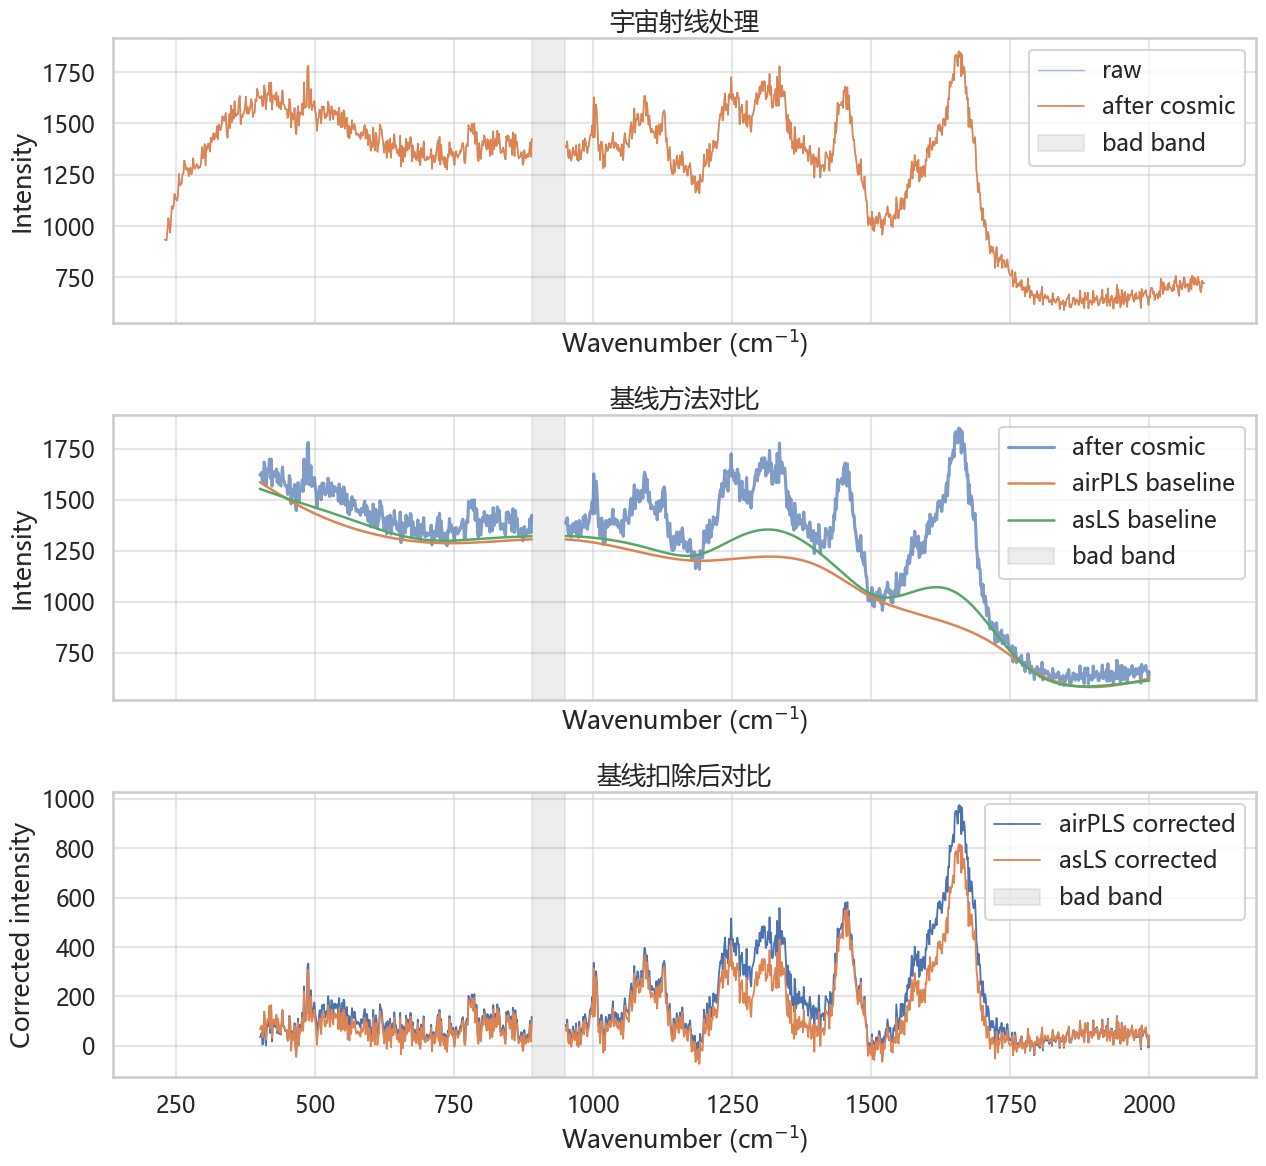

In [30]:
SAMPLE_PATH = None

SAMPLE_FOLDER = None
SAMPLE_SEED = None
PROFILE_ID = "GN"
DISPLAY_MIN = None
DISPLAY_MAX = None

show_preprocess(
    profile_id=PROFILE_ID,
    sample_path=SAMPLE_PATH,
    sample_folder=SAMPLE_FOLDER,
    sample_seed=SAMPLE_SEED,
    display_min=DISPLAY_MIN,
    display_max=DISPLAY_MAX,
    compare_baselines=True,
)